### ![alt text](https://nexteducacion.com/wp-content/uploads/2020/02/cropped-next-educaci%C3%B3n.png.webp "nextEDUCACION")
### Máster en Big Data y Business Intelligence.

### Obtencion de Datos para el TFM.
**Autores**
- David Mejía Cascante
- Daniel Vargas Salazar
- Juan Luis Chávez Mejía
- María Cubero Sandoval
- Melany Jiménez Nin

### Asignatura 7. Modelado Predictivo con Machine Learning
### **Profesor: **
### Fecha: 28 de Marzo del 2026.

## 1. Selección del dataset

Se ha elegido, High overcommitment and low reward as potential predictors for increased depressive symptoms, suicidal ideation, and suicide risk in German veterinarians, este data set no cuenta un API para su llamado.

**Dataset:** https://www.ebi.ac.uk/biostudies/europepmc/studies/S-EPMC11421818

## 2. Objetivos.

Objetivos

## 3. Limpieza y preparación de los datos

### A. Preparacion del entorno y librerias necesarias.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import caret as ct
import joblib

url = 'https://raw.githubusercontent.com/davidmejiacascante/next_a7/main/data/Veterinarians%20In%20germany.xlsx'
df = pd.read_excel(url, engine='openpyxl')

### B. Cargar los datos del dataset.

In [82]:
print("Cantidad de datos y dimensiones en el data set de Netflix: ",df.shape)

Cantidad de datos y dimensiones en el data set de Netflix:  (3179, 57)


In [83]:
print("Resumen del data set, variables, cantidad de nulos y tipos de datos: ")
df.info()

Resumen del data set, variables, cantidad de nulos y tipos de datos: 
<class 'pandas.DataFrame'>
RangeIndex: 3179 entries, 0 to 3178
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   SBQR 1_attempt                            3153 non-null   float64
 1   SBQR 2_frequency                          3153 non-null   float64
 2   SBQR 3_thread                             3153 non-null   float64
 3   SBQR4_likelihood                          3153 non-null   float64
 4   SBQ_SUMN                                  3153 non-null   float64
 5   SBQ_CUTN                                  3153 non-null   float64
 6   ERI_1                                     3178 non-null   float64
 7   ERI_2                                     3178 non-null   float64
 8   ERI_3                                     3178 non-null   float64
 9   ERI_4                                     3178 n

In [84]:
df = df.drop_duplicates().copy()
df.shape

(3179, 57)

In [85]:
print("Observaciones:", df.shape[0])

Observaciones: 3179


In [86]:
print("Variables:", df.shape[1])

Variables: 57


In [87]:
print("Lista de variables:", list(df.columns))

Lista de variables: ['SBQR 1_attempt', 'SBQR 2_frequency', 'SBQR 3_thread', 'SBQR4_likelihood', 'SBQ_SUMN', 'SBQ_CUTN', 'ERI_1', 'ERI_2', 'ERI_3', 'ERI_4', 'ERI_5', 'ERI_6', 'ERI_7', 'ERI_8', 'ERI_9', 'ERI_10', 'COPSOQ_B1 (quantitative demands)', 'B2', 'B3', 'B4', 'COPSOQ_emotional demands (ED)_01', 'ED_02', 'ED_03', 'COPSOQ_demands_for_hiding_emotions (DHD)', 'DHD_02', 'COPSQO work-privacy-conlfict (wpc)_01', 'WPC_02', 'WPC_03', 'WPC_4', 'WPC_05', 'COPSOQ B10', 'CBI_01', 'CBI_02', 'CBI_03', 'CBI_04', 'CBI_05', 'CBI_06', 'COPSOQ-meaning_of_work-(mow)_01', 'mow_02', 'mow_03', 'PHQ9_01', 'PHQ9_02', 'PHQ9_03', 'PHQ9_04', 'PHQ9_05', 'PHQ9_06', 'PHQ9_07', 'PHQ9_08', 'PHQ9_09', 'gender', 'birth year', 'status of employment', 'field of work', 'federal state', 'community size', 'income', 'working hours']


In [88]:
print("Valores nulos en el dataset: ")
df.isna().sum().sort_values(ascending=False)

Valores nulos en el dataset: 


working hours                               53
SBQR 2_frequency                            26
SBQR 3_thread                               26
SBQR4_likelihood                            26
SBQ_SUMN                                    26
SBQ_CUTN                                    26
SBQR 1_attempt                              26
birth year                                   9
community size                               4
income                                       4
ERI_5                                        1
ERI_6                                        1
ERI_7                                        1
ERI_4                                        1
ERI_9                                        1
ERI_10                                       1
COPSOQ_B1 (quantitative demands)             1
B2                                           1
B3                                           1
B4                                           1
COPSOQ_emotional demands (ED)_01             1
ERI_8        

In [89]:
print("Eliminar valores nulos.")
df = df.dropna()

Eliminar valores nulos.


In [90]:
print("Valores duplicados en el dataset: ",df.duplicated().sum())

Valores duplicados en el dataset:  0


### C. Revisión de tipos de datos y columnas.

Eliminar las columnas que no se usaran para el TFM.

In [91]:
df = df.drop(columns=["SBQR 1_attempt","SBQR 2_frequency","SBQR 3_thread","SBQR4_likelihood","SBQ_SUMN","SBQ_CUTN","COPSOQ-meaning_of_work-(mow)_01","mow_02","mow_03","PHQ9_01","PHQ9_02","PHQ9_03","PHQ9_04","PHQ9_05","PHQ9_06","PHQ9_07","PHQ9_08","PHQ9_09"])
df.head()

,ERI_1,ERI_2,ERI_3,ERI_4,ERI_5,ERI_6,ERI_7,ERI_8,ERI_9,ERI_10,...,CBI_05,CBI_06,gender,birth year,status of employment,field of work,federal state,community size,income,working hours
0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,2.0,2.0,1.0,...,4.0,3.0,2.0,1986,9.0,12.0,-2.0,2.0,1.0,60
1,2.0,2.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,...,2.0,1.0,2.0,1980,2.0,9.0,4.0,2.0,3.0,35
2,3.0,3.0,3.0,3.0,2.0,2.0,1.0,3.0,3.0,3.0,...,4.0,3.0,2.0,1989,2.0,9.0,4.0,1.0,3.0,42
3,3.0,4.0,4.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,...,4.0,2.0,2.0,1984,2.0,5.0,4.0,3.0,3.0,45
4,3.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,3.0,...,1.0,1.0,1.0,1978,2.0,2.0,4.0,4.0,2.0,40


In [92]:
# --------------------------------------------
# CÓDIGOS ESPECIALES
# (-1, -2, -9 como missing)
# --------------------------------------------
df = df.replace([-1, -2, -9], np.nan)

### E. Feature engineering.

In [93]:
# ------------------------------------------------------------
# Variable objetivo: Burn out score
# ------------------------------------------------------------
df['promedio_cbi'] = round(df[['CBI_01','CBI_02','CBI_03','CBI_04','CBI_05','CBI_06']].mean(axis=1), 1)

def crear_target_burnout(df, percentile=0.80):
    df = df.copy()
    threshold = df["promedio_cbi"].quantile(percentile)
    df["Burnout_Score"] = (df["promedio_cbi"] >= threshold).astype(int)
    return df

df = crear_target_burnout(df)

In [94]:
# def crear_target_burnout(df, percentile=0.80, labels=("Low", "High"), as_int=False):
#     df = df.copy()
#     threshold = df["promedio_cbi"].quantile(percentile)
#     mask = df["promedio_cbi"] >= threshold
#     if as_int:
#         df["Burnout_Score"] = mask.astype(int)
#     else:
#         df["Burnout_Score"] = np.where(mask, labels[1], labels[0])
#     return df

# df = crear_target_burnout(df)

In [95]:
df["birth year"] = pd.to_numeric(df["birth year"], errors='coerce').astype('Int64')
df["working hours"] = pd.to_numeric(df["working hours"], errors='coerce').astype('Int64')
df.loc[(df["birth year"] <= 1951) & (df["birth year"] >= 2004), "birth year"] = np.nan
df.loc[(df["working hours"] >= 100) & (df["working hours"] <=5), "working hours"] = np.nan
df = df.dropna()

In [96]:
print("Eliminar valores nulos.")
df = df.dropna()

Eliminar valores nulos.


In [97]:
df.shape

(2233, 41)

In [98]:
df.head()

,ERI_1,ERI_2,ERI_3,ERI_4,ERI_5,ERI_6,ERI_7,ERI_8,ERI_9,ERI_10,...,gender,birth year,status of employment,field of work,federal state,community size,income,working hours,promedio_cbi,Burnout_Score
1,2.0,2.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,...,2.0,1980,2.0,9.0,4.0,2.0,3.0,35,2.0,0
2,3.0,3.0,3.0,3.0,2.0,2.0,1.0,3.0,3.0,3.0,...,2.0,1989,2.0,9.0,4.0,1.0,3.0,42,3.5,0
3,3.0,4.0,4.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,...,2.0,1984,2.0,5.0,4.0,3.0,3.0,45,3.3,0
4,3.0,3.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,3.0,...,1.0,1978,2.0,2.0,4.0,4.0,2.0,40,1.2,0
6,2.0,4.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,...,2.0,1968,2.0,13.0,8.0,2.0,3.0,38,3.3,0


## 4. Analisis exploratorio de datos (EDA).

### 4.1 Análisis univariante:

In [99]:
# --------------------------------------------
# Univariantes
# --------------------------------------------
# numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# for col in numeric_cols:
#     plt.figure(figsize=(5,3))
#     sns.histplot(df[col].dropna(), kde=True)
#     plt.title(f"Distribución de {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frecuencia")
#     plt.tight_layout()
#     plt.show()

In [100]:
# --------------------------------------------
# BOXPLOTS (OUTLIERS)
# --------------------------------------------
# for col in numeric_cols:
#     plt.figure(figsize=(5,2))
#     sns.boxplot(x=df[col])
#     plt.title(f"Boxplot de {col}")
#     plt.tight_layout()
#     plt.show()

### 4.2 Análisis Bivariante

## 5. Modelos Predictivos

### árbol de decisión

Accuracy: 1.0
Classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00       498
           1       1.00      1.00      1.00       172

    accuracy                           1.00       670
   macro avg       1.00      1.00      1.00       670
weighted avg       1.00      1.00      1.00       670

Confusion matrix:\n [[498   0]
 [  0 172]]


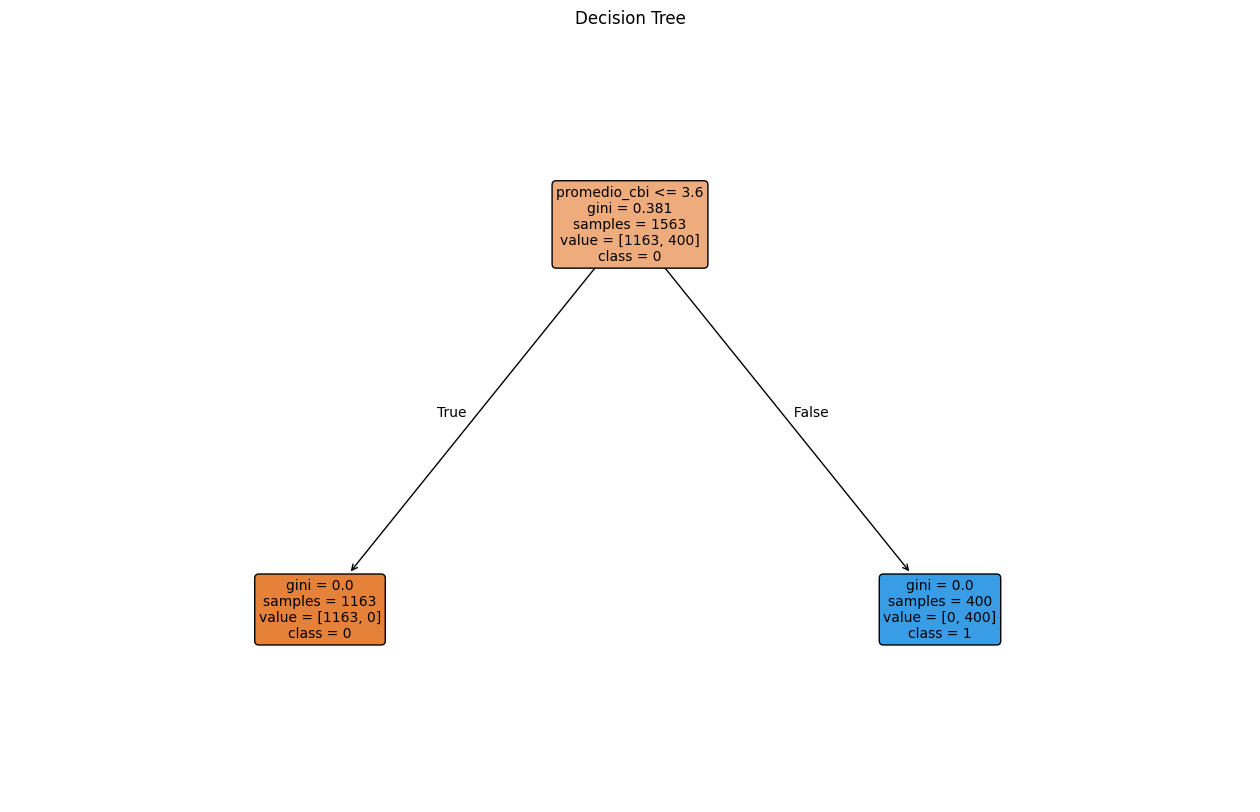

In [101]:
# --------------------------------------------
# árbol de decisión para clasificar variables discretas
# --------------------------------------------
# 2) características y etiquetas
X = df.drop(columns=["Burnout_Score"])
y = df["Burnout_Score"]

# 3) split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=52, stratify=y
)

# 4) modelo
clf = DecisionTreeClassifier(random_state=528, max_depth=4)  # max_depth optional
clf.fit(X_train, y_train)

# 5) predecir y evaluar
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\\n", classification_report(y_test, y_pred))
print("Confusion matrix:\\n", confusion_matrix(y_test, y_pred))

# 6) arbol de decisión
plt.figure(figsize=(16, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree")
plt.show()

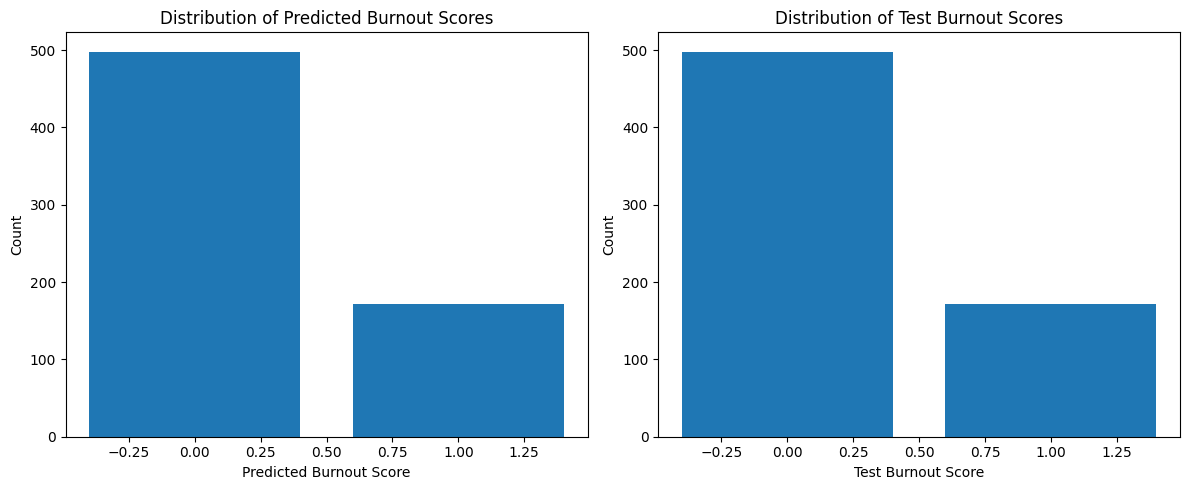

In [102]:
count_pred = pd.Series(y_pred).value_counts()
count_test = pd.Series(y_test).value_counts()

# 1. Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot on the first subplot (ax1)
ax1.bar(count_pred.index, count_pred.values)
ax1.set_xlabel('Predicted Burnout Score')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Predicted Burnout Scores')

# 3. Plot on the second subplot (ax2)
ax2.bar(count_test.index, count_test.values)
ax2.set_xlabel('Test Burnout Score')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Test Burnout Scores')

# 4. Display the plots together
plt.tight_layout() # Ensures labels don't overlap
plt.show()

Accuracy: 1.0
Classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00       498
           1       1.00      1.00      1.00       172

    accuracy                           1.00       670
   macro avg       1.00      1.00      1.00       670
weighted avg       1.00      1.00      1.00       670

Confusion matrix:\n [[498   0]
 [  0 172]]


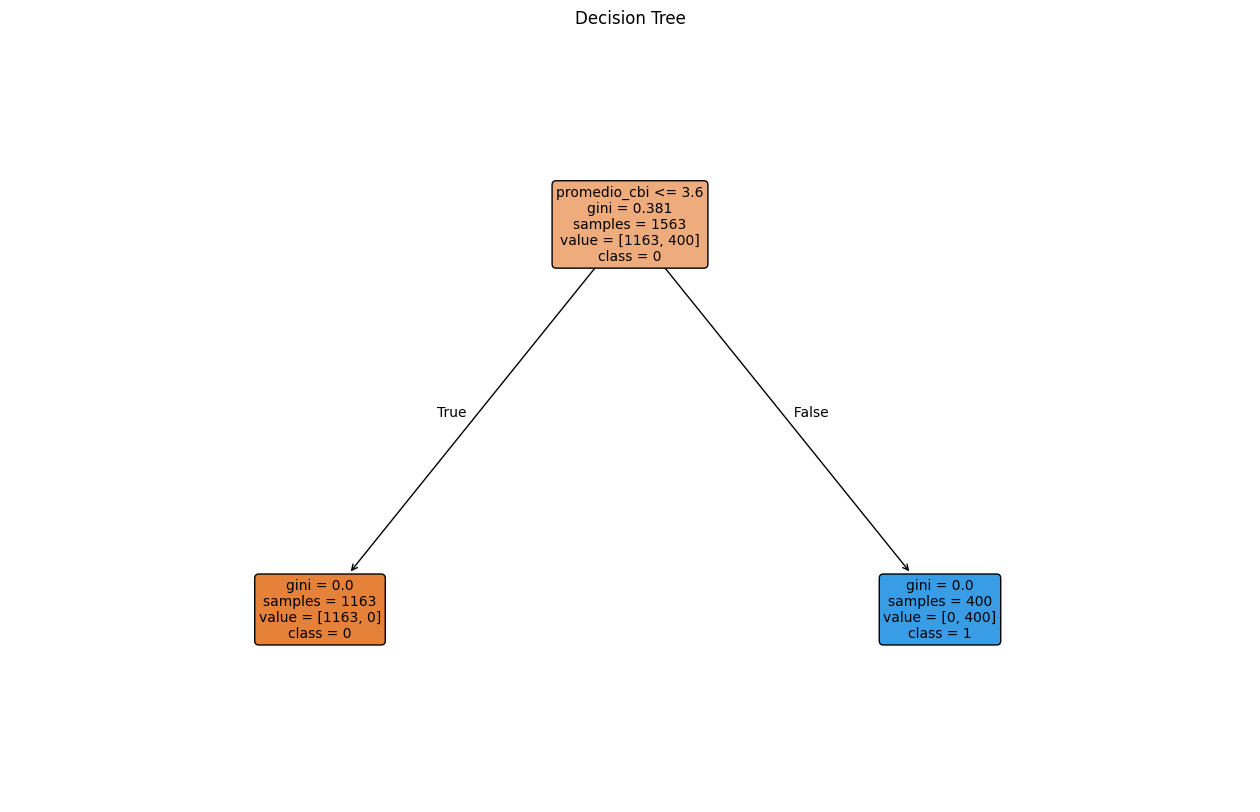

In [103]:
# Creamos un segundo arbol de decisión
clf2 = DecisionTreeClassifier(random_state=1528, max_depth=3)  # max_depth optional
clf2.fit(X_train, y_train)

# 5) predecir y evaluar
y_pred2 = clf2.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Classification report:\\n", classification_report(y_test, y_pred2))
print("Confusion matrix:\\n", confusion_matrix(y_test, y_pred2))

# 6) arbol de decisión
plt.figure(figsize=(16, 10))
plot_tree(
    clf2,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree")
plt.show()

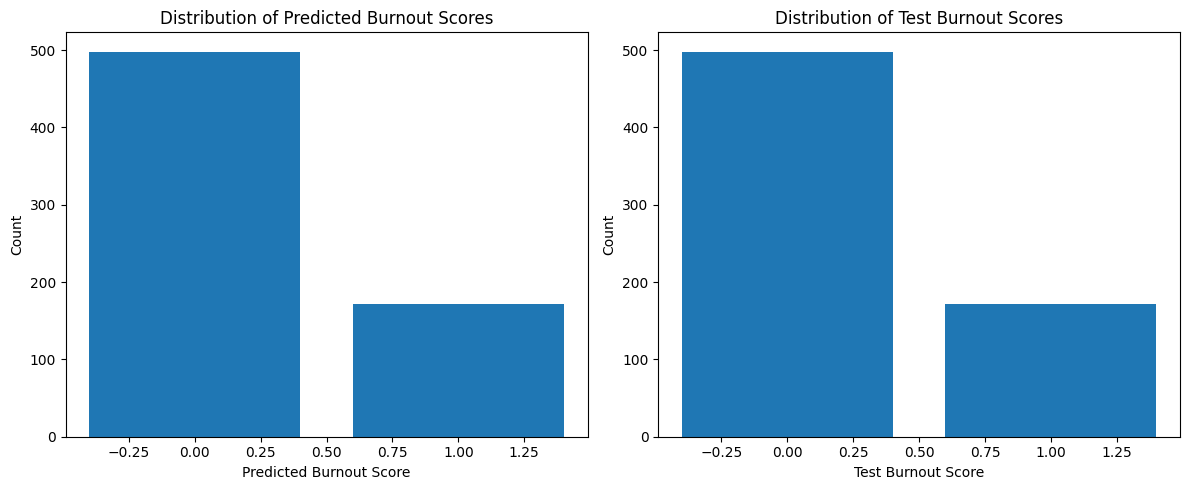

In [104]:
count_pred = pd.Series(y_pred2).value_counts()
count_test = pd.Series(y_test).value_counts()

# 1. Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot on the first subplot (ax1)
ax1.bar(count_pred.index, count_pred.values)
ax1.set_xlabel('Predicted Burnout Score')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Predicted Burnout Scores')

# 3. Plot on the second subplot (ax2)
ax2.bar(count_test.index, count_test.values)
ax2.set_xlabel('Test Burnout Score')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Test Burnout Scores')

# 4. Display the plots together
plt.tight_layout() # Ensures labels don't overlap
plt.show()

### Random Forest

B. Modelo de regresión

Accuracy: 1.0
Classification report:\n               precision    recall  f1-score   support

           0       1.00      1.00      1.00       498
           1       1.00      1.00      1.00       172

    accuracy                           1.00       670
   macro avg       1.00      1.00      1.00       670
weighted avg       1.00      1.00      1.00       670

Confusion matrix:\n [[498   0]
 [  0 172]]


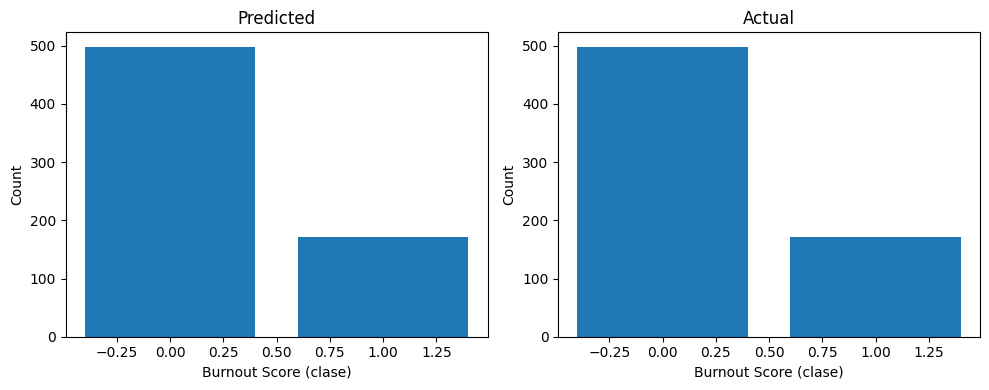

In [106]:
# --------------------------------------------
# Random Forest
# --------------------------------------------
# características y etiquetas
X = df.drop(columns=["Burnout_Score"])
y = df["Burnout_Score"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=52, stratify=y
)

# modelo
rf_clf = RandomForestClassifier(random_state=0, n_estimators=100)
rf_clf.fit(X_train, y_train)

# predecir y evaluar
y_pred = rf_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\\n", classification_report(y_test, y_pred))
print("Confusion matrix:\\n", confusion_matrix(y_test, y_pred))

count_pred = pd.Series(y_pred).value_counts().sort_index()
count_test = pd.Series(y_test).value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].bar(count_pred.index, count_pred.values); axes[0].set_title("Predicted")
axes[1].bar(count_test.index, count_test.values); axes[1].set_title("Actual")
for ax in axes:
    ax.set_xlabel("Burnout Score (clase)")
    ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

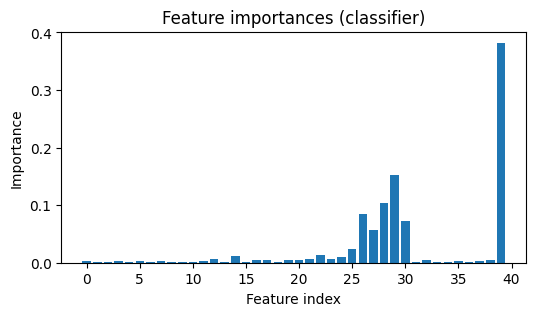

In [107]:
# Importancias de características
importances = rf_clf.feature_importances_
plt.figure(figsize=(6,3))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature index"); plt.ylabel("Importance")
plt.title("Feature importances (classifier)")
plt.show()



In [108]:
# Guardar modelo
joblib.dump(rf_clf, "rf_classifier.joblib")


# --- Regresión (Diabetes) ---
Xr, yr = load_diabetes(return_X_y=True)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, random_state=0)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg.fit(Xr_train, yr_train)

yr_pred = rf_reg.predict(Xr_test)
print("R2 score (regressor):", rf_reg.score(Xr_test, yr_test))



R2 score (regressor): 0.21875829183896933


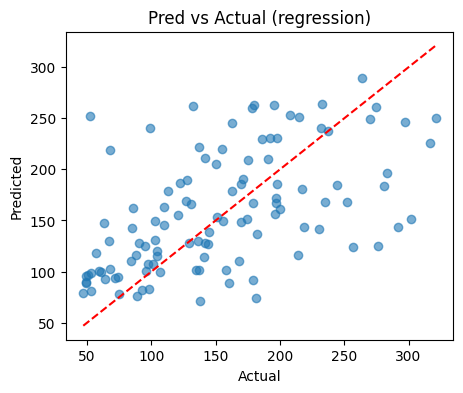

['rf_regressor.joblib']

In [109]:
# Comparación simple: scatter pred vs actual
plt.figure(figsize=(5,4))
plt.scatter(yr_test, yr_pred, alpha=0.6)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Pred vs Actual (regression)")
plt.show()

joblib.dump(rf_reg, "rf_regressor.joblib")

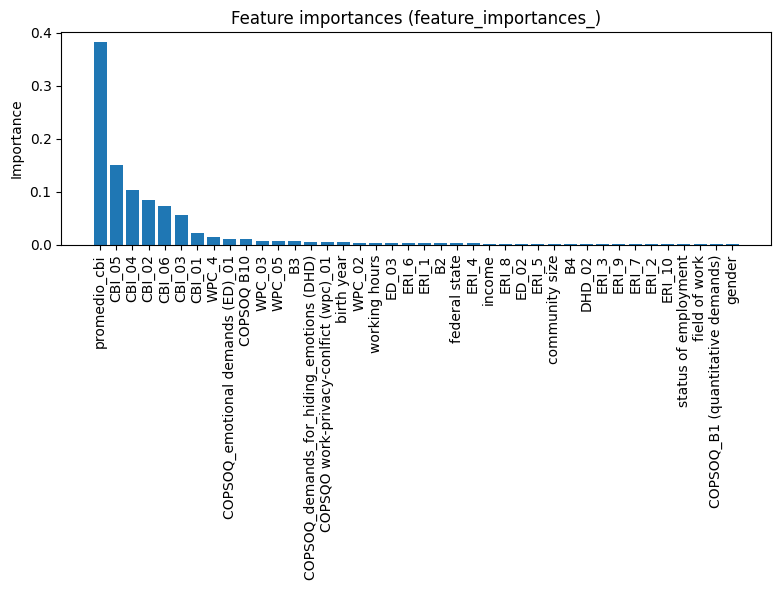

In [113]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), np.array(rf_clf.feature_names_in_)[indices], rotation=90)
plt.ylabel('Importance')
plt.title('Feature importances (feature_importances_)')
plt.tight_layout()
plt.show()

C:\Users\DAVID\AppData\Local\Temp\ipykernel_15444\54085913.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=names)


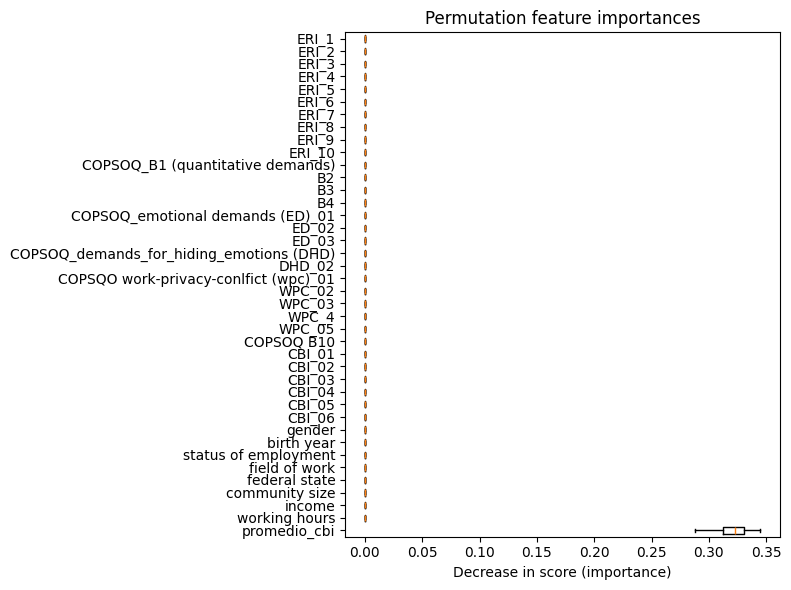

In [115]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_clf, X_test, y_test, n_repeats=30, random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[::-1]
names = np.array(rf_clf.feature_names_in_)[sorted_idx]

plt.figure(figsize=(8,6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=names)
plt.xlabel("Decrease in score (importance)")
plt.title("Permutation feature importances")
plt.tight_layout()
plt.show()

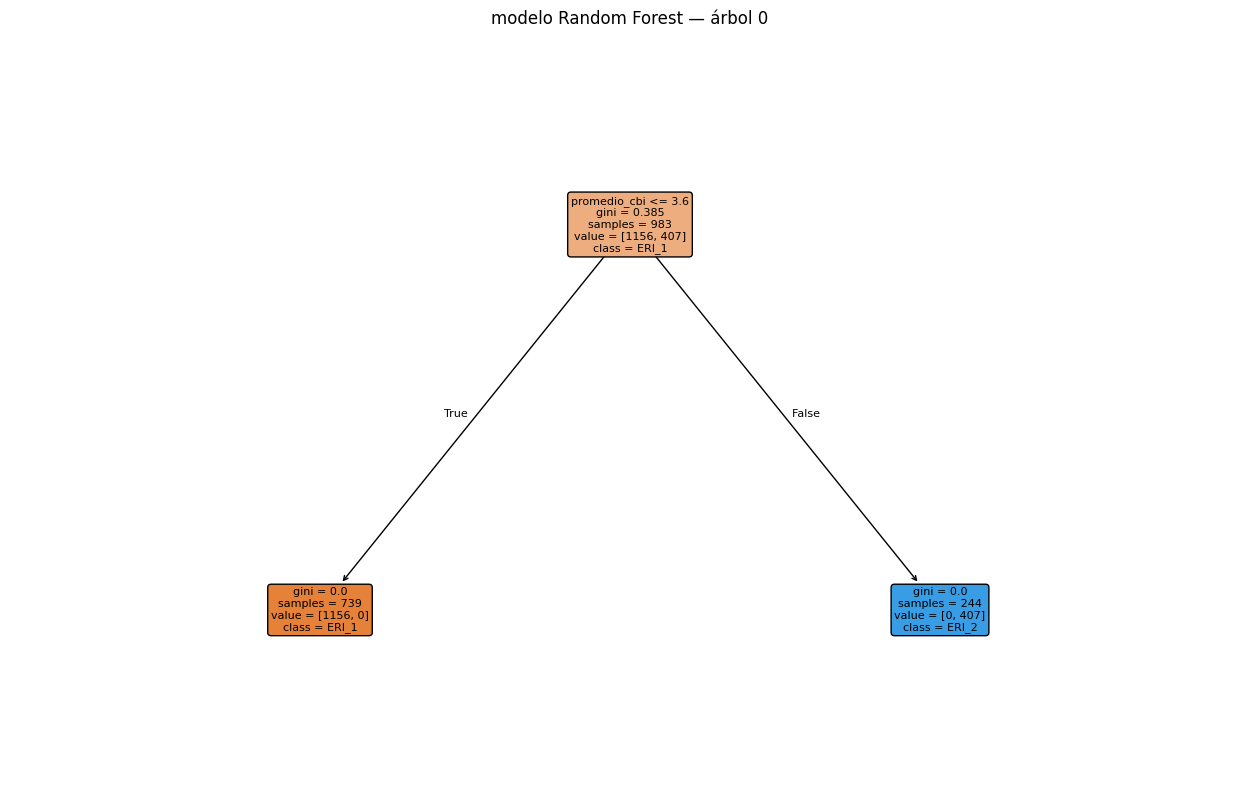

In [119]:
from sklearn import tree

plt.figure(figsize=(16,10))
tree.plot_tree(rf_clf.estimators_[0],
               feature_names=rf_clf.feature_names_in_,
               class_names=rf_clf.feature_names_in_ if hasattr(rf_clf, "classes_") else None,
               filled=True,
               rounded=True,
               fontsize=8)
plt.title("modelo Random Forest — árbol 0")
plt.show()

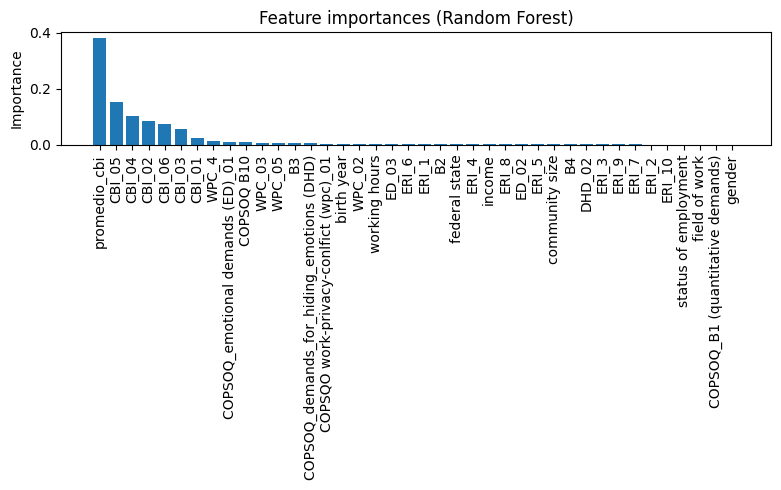

In [120]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_clf.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure(figsize=(8,5))
plt.bar(np.arange(len(importances)), importances[idx])
plt.xticks(np.arange(len(importances)), np.array(rf_clf.feature_names_in_)[idx], rotation=90)
plt.ylabel("Importance")
plt.title("Feature importances (Random Forest)")
plt.tight_layout()
plt.show()

c:\Users\DAVID\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\DAVID\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\DAVID\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\DAVID\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\DAVID\A

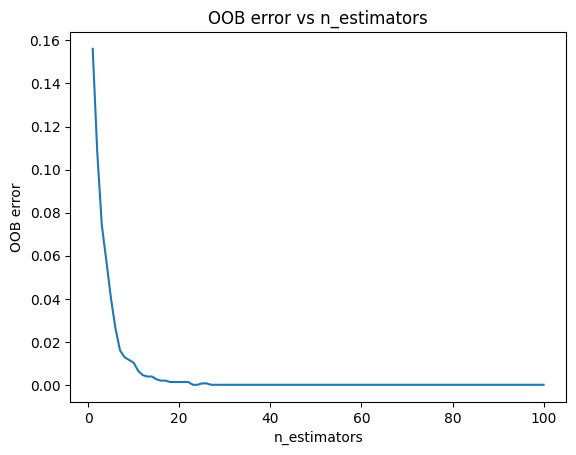

In [121]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=0)
oob_errors = []
n_max = 100
for n in range(1, n_max+1):
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.plot(range(1, n_max+1), oob_errors)
plt.xlabel("n_estimators")
plt.ylabel("OOB error")
plt.title("OOB error vs n_estimators")
plt.show()

## 6. Modelo Avanzado

A. Uno de estos:

- Modelo multiclase.
- Modelo ensemble.
- Red neuronal.
- Modelo temporal.
- Sistema de recomendación.
- Pipeline automatizado.

## 7. Análisis No Supervisado o Segmentación

### Aplicar al menos una técnica no supervisada:
- Clustering.
- Reducción de dimensionalidad.
- Segmentación de usuarios o entidades.